# Classificação de Exoplanetas: Análise e Modelagem Preditiva

Antônio Ferreira Oliveira Santos - nUSP: 13863967  
Felipe Oliveira Leiras da Mota - nUSP: 14675969  
Karine dos Santos Toledo - nUSP: 13671171  

---

Este projeto tem como objetivo desenvolver um classificador robusto para categorizar exoplanetas (ex: Super-Terras, Gigantes Gasosos) utilizando dados observacionais da NASA.  

O dataset escolhido foi baixado do Kaggle e está disponível em: [NASA Exoplanets](https://www.kaggle.com/datasets/adityamishraml/nasaexoplanets)

**O fluxo desse trabalho consiste na aplicação das técnicas habituais em um projeto de Ciência de Dados:**
* **1. Pré-processamento:** Normalização de unidades físicas e limpeza de dados.
* **2. Imputação Avançada:** Uso de regressão (Random Forest) para recuperar dados faltantes sem introduzir viés.
* **3. Análise Exploratória (EDA):** Estudo das correlações físicas (Massa x Raio) e distribuições orbitais.
* **4. Modelagem:** Treinamento e comparação competitiva entre **Random Forest** e **KNN**.
* **5. Validação:** Testes de robustez estatística (Bootstrap, PCA e Ablation Study).

---

In [1]:
# Importando todas as bibliotecas e módulos do Python

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, classification_report,
                             accuracy_score, confusion_matrix)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.utils import resample

# Configurações globais
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [2]:
# Carregando os dados brutos
df_original = pd.read_csv("dataset/cleaned_5250.csv")
df = df_original.copy()

print(f"Dimensões do dataset: {df.shape}")
display(df.head())

Dimensões do dataset: (5250, 13)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


### 1. Normalização de Unidades Físicas (Feature Engineering)

O dataset original apresenta inconsistências nas unidades de medida: alguns planetas são comparados à Terra, outros a Júpiter. Para que os modelos matemáticos funcionem corretamente, precisamos de uma escala única.

**Estratégia de Tratamento:**
* **Padronização:** Converteremos todas as medidas de massa e raio para a escala de **Júpiter**.
* **Justificativa:** A escala de Júpiter facilita a visualização logarítmica e a comparação entre gigantes gasosos e planetas rochosos, evitando distorções numéricas nos algoritmos de distância (como o KNN).

---

In [3]:
# Fatores de conversão (Terra -> Júpiter)
FATOR_MASSA_JUPITER = 317.8
FATOR_RAIO_JUPITER = 11.2

# Conversão de Massa
mask_massa = df['mass_wrt'] == 'Earth'
df.loc[mask_massa, 'mass_multiplier'] /= FATOR_MASSA_JUPITER

# Conversão de Raio
mask_raio = df['radius_wrt'] == 'Earth'
df.loc[mask_raio, 'radius_multiplier'] /= FATOR_RAIO_JUPITER

# Remoção de colunas auxiliares e metadados irrelevantes para o modelo
cols_drop = ['mass_wrt', 'radius_wrt', 'distance', 'name', 'discovery_year', 'detection_method']
df.drop(columns=cols_drop, inplace=True)

### 2. Diagnóstico de Qualidade de Dados (Data Quality)

Antes da modelagem, é crucial identificar a "saúde" do dataset. Dados faltantes (*missing values*) são comuns em astronomia devido às limitações dos telescópios, mas que podem quebrar os modelos preditivos.

---

Valores nulos por coluna:
stellar_magnitude    161
mass_multiplier       23
radius_multiplier     17
orbital_radius       289
dtype: int64


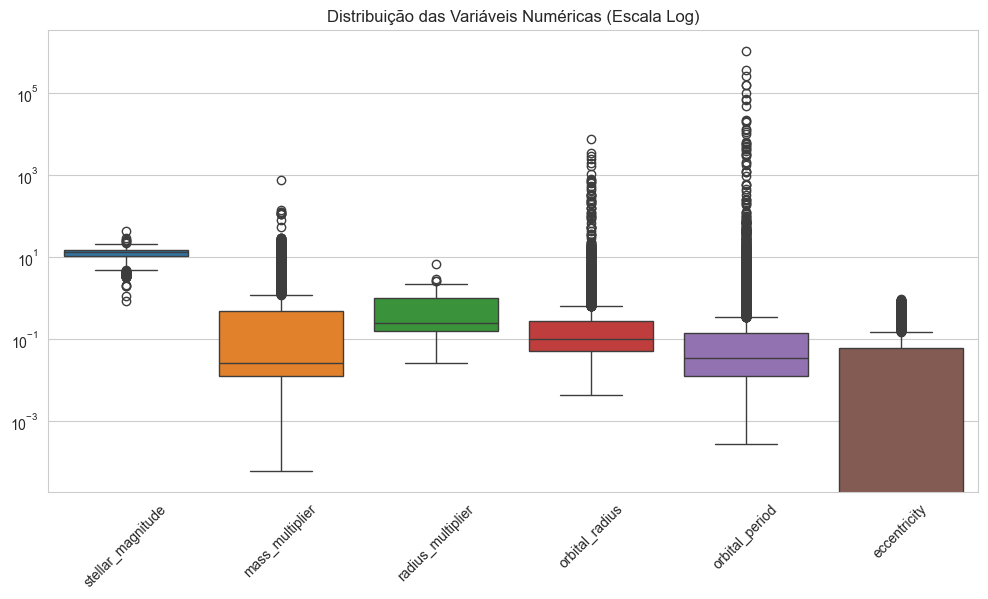

In [4]:
# Volumetria de nulos
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Análise de Outliers (Escala Log para melhor visualização)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.yscale("log")
plt.title("Distribuição das Variáveis Numéricas (Escala Log)")
plt.xticks(rotation=45)
plt.show()

### 3. Estratégia de Imputação via Machine Learning

Detectamos uma quantidade significativa de valores nulos além de uma presença considerável de outliers. Preenchê-los com a **Média** ou **Mediana** seria cientificamente incorreto, pois a física dos planetas não segue uma distribuição normal simples.  

Apesar da presença de vários outliers esses dados não devem afetar significamente a qualidade do estimador e dizem mais sobre a grande dispersão de dados astrônomicos.

**Decisão Técnica (Random Forest Imputer):**
* **Método:** Utilizaremos um modelo de regressão para *prever* os valores faltantes com base nas outras características conhecidas do planeta.
* **Vantagem:** Isso preserva as correlações não-lineares (ex: a relação entre Massa e Raio) e mantém a integridade física dos dados sintéticos.

---

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

# Eliminando os planetas do tipo 'Unknown', pois são poucos e interferem na qualidade do estimador
df = df[df['planet_type'] != 'Unknown']

# 1. Separar Features (X) e Target (y)
X = df.drop(columns=['planet_type'])
y = df['planet_type']

# 2. Divisão Treino/Teste (Usamos stratify=y para manter a proporção das classes de planetas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Imputação via KNN
imputer = KNNImputer(n_neighbors=5)

# As colunas perdem os nomes ao passar pelo imputer, então salvamos para repor depois
cols = X_train.columns

X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=cols, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=cols, index=X_test.index)

print("Imputação concluída")

# 4. Criar um DataFrame temporário APENAS para os gráficos (EDA) das células seguintes
df_reg = X_train_imputed.copy()
df_reg['planet_type'] = y_train

Imputação concluída


### 4. Análise Exploratória (EDA): A Relação Massa-Raio

Este é o gráfico mais fundamental da astrofísica planetária. Ao plotar Massa vs. Raio em escala logarítmica, esperamos observar a separação natural dos corpos celestes.

**O que buscar na visualização:**
* **Clusters Definidos:** Agrupamentos visuais que diferenciam planetas rochosos (densos) de gasosos (pouco densos).
* **Radius Valley:** Uma lacuna esperada entre Super-Terras e Mini-Netunos, onde poucos planetas conseguem manter suas atmosferas.

---

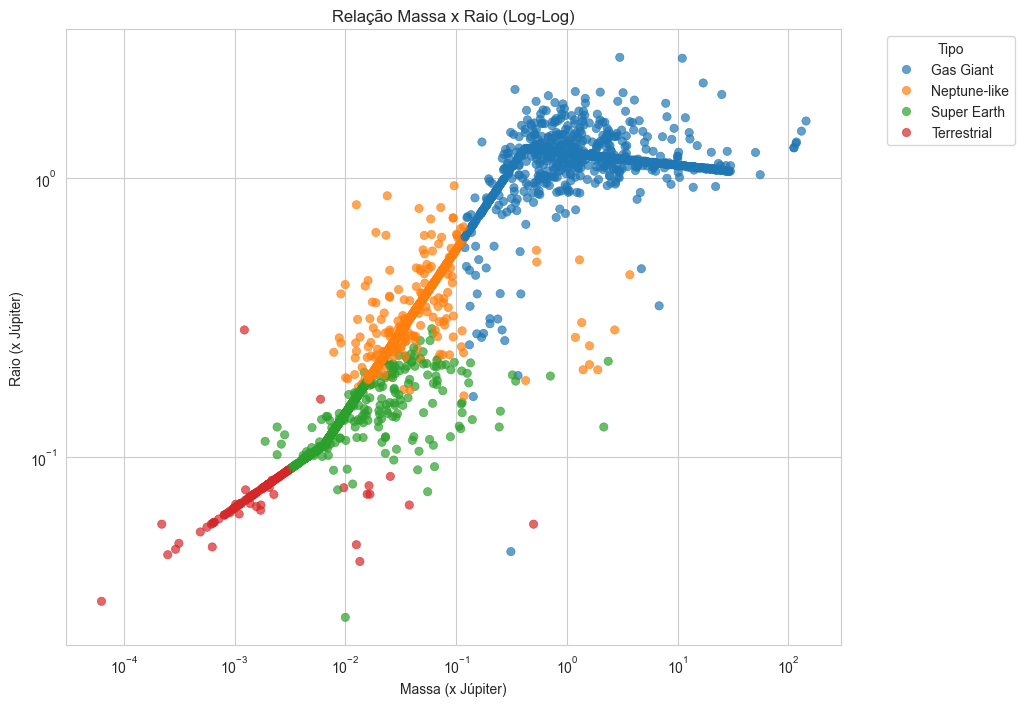

In [6]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_reg, x='mass_multiplier', y='radius_multiplier',
                hue='planet_type', alpha=0.7, edgecolor=None)

plt.xscale('log')
plt.yscale('log')
plt.title('Relação Massa x Raio (Log-Log)')
plt.xlabel('Massa (x Júpiter)')
plt.ylabel('Raio (x Júpiter)')
plt.legend(title='Tipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 5. Distribuição Orbital e Viés de Detecção

Analisamos abaixo a distribuição dos períodos orbitais (a duração do "ano" em cada planeta).

**Interpretação do Viés:**
* **Concentração em Períodos Curtos:** A maioria dos exoplanetas descobertos orbita muito perto de suas estrelas. Isso ocorre porque os métodos de Trânsito e Velocidade Radial detectam esses planetas com muito mais facilidade.
* **Impacto no Modelo:** O modelo será naturalmente melhor em classificar "Júpiters Quentes" do que planetas em zonas habitáveis distantes, devido à maior quantidade de exemplos de treino.

---

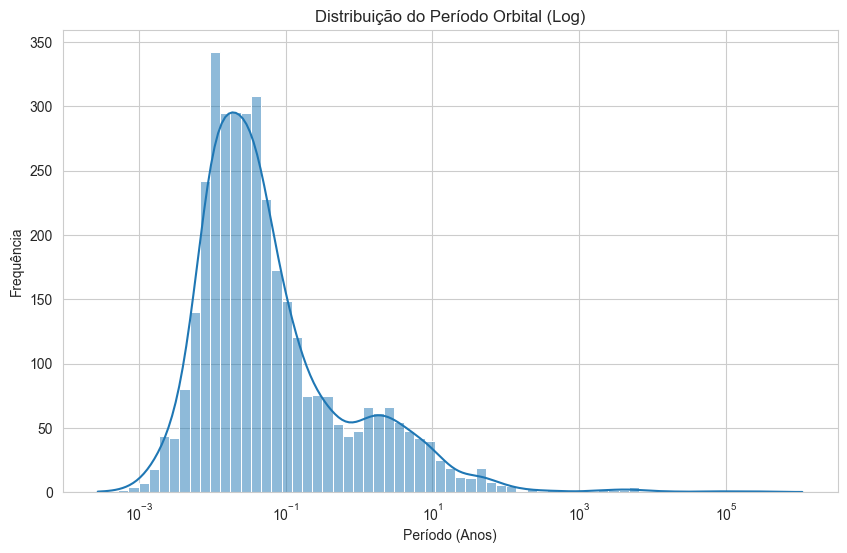

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_reg, x='orbital_period', kde=True, log_scale=True)
plt.title('Distribuição do Período Orbital (Log)')
plt.xlabel('Período (Anos)')
plt.ylabel('Frequência')
plt.show()

### 6. Análise de Multicolinearidade

Para selecionar as melhores *features*, precisamos entender como as variáveis interagem entre si. Variáveis altamente correlacionadas podem trazer redundância desnecessária.

**Leitura do Heatmap:**
* **Alta Correlação (Vermelho):** Indica redundância (ex: Massa e Raio). Embora redundantes, ambas são cruciais para distinguir a densidade.
* **Baixa Correlação (Azul):** Indica independência, adicionando novas informações valiosas ao modelo (ex: Excentricidade da órbita).

---

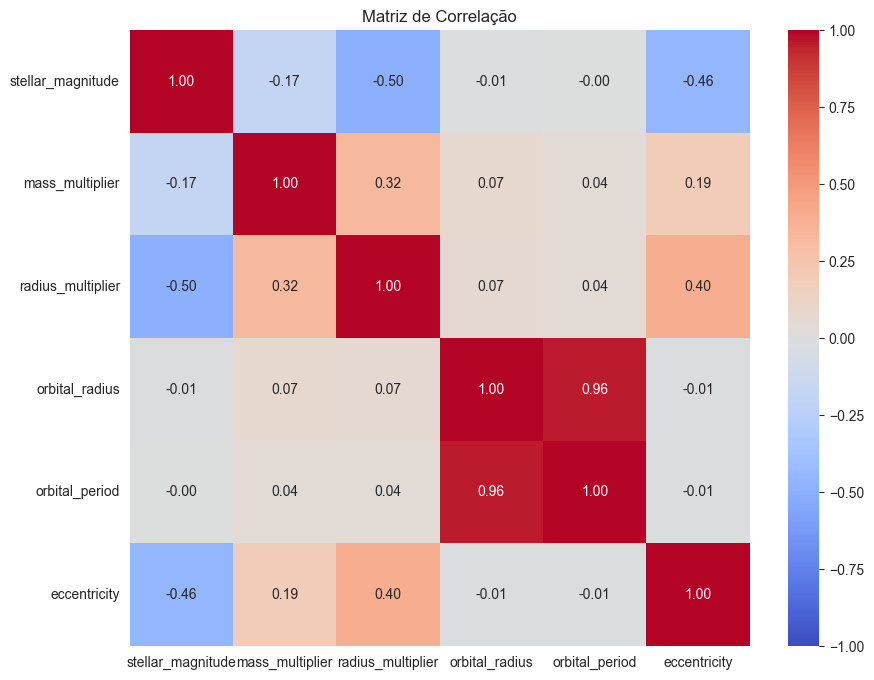

In [8]:
# Correlação apenas das variáveis numéricas físicas/orbitais
cols_corr = ['stellar_magnitude', 'mass_multiplier', 'radius_multiplier',
             'orbital_radius', 'orbital_period', 'eccentricity']

plt.figure(figsize=(10, 8))
sns.heatmap(df_reg[cols_corr].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

### 7. Modelagem Preditiva: Random Forest (Baseline)

Optamos pelo **Random Forest Classifier** como nosso modelo principal.

**Por que esta escolha?**
* **Não-Linearidade:** Capaz de capturar fronteiras de decisão complexas e irregulares entre os tipos de planetas.
* **Robustez:** Lida bem com *outliers* e não exige que os dados estejam na mesma escala numérica (ao contrário de Redes Neurais).
* **Interpretale:** Permite-nos extrair a "importância das features" para validar as hipóteses físicas.

---

Acurácia (Random Forest): 0.9746

Report de Classificação:
               precision    recall  f1-score   support

   Gas Giant       0.99      1.00      0.99       489
Neptune-like       0.96      0.97      0.97       548
 Super Earth       0.98      0.95      0.97       479
 Terrestrial       0.97      0.98      0.97        58

    accuracy                           0.97      1574
   macro avg       0.97      0.98      0.97      1574
weighted avg       0.97      0.97      0.97      1574



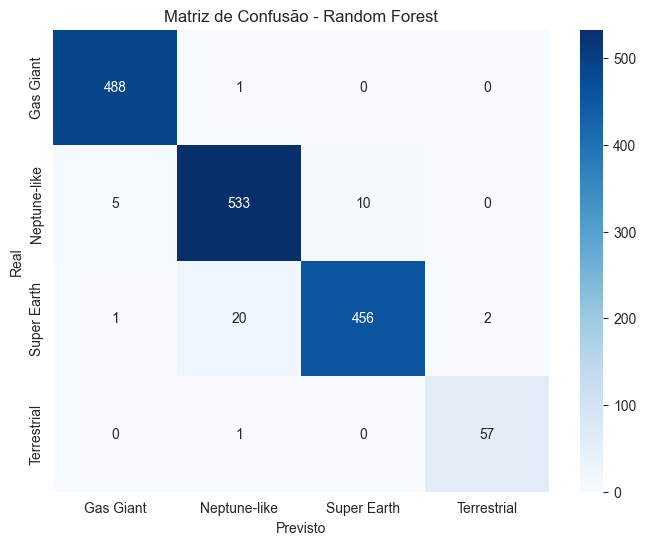

In [9]:

# 1. Escolhendo o modelo de RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100, 
    n_jobs=-1, 
    random_state=42,
    class_weight='balanced' # Ajuda o modelo a prestar atenção nos planetas raros (Terrestres)
)

# 2. Treinamento
rf.fit(X_train_imputed, y_train)

# 3. Predições
y_pred_rf = rf.predict(X_test_imputed)

# 4. Avaliação
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia (Random Forest): {acc_rf:.4f}")
print("\nReport de Classificação:\n", classification_report(y_test, y_pred_rf))

# 5. Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### 8. Refinamento de Hiperparâmetros (Tuning)

O modelo base já apresenta resultados promissores, mas podemos extrair mais performance ajustando seus "botões" de controle.

**Estratégia (GridSearch):**
* **Objetivo:** Encontrar o equilíbrio ótimo entre *Underfitting* (modelo muito simples) e *Overfitting* (modelo que decora os dados).
* **Parâmetros:** Testaremos variações no número de árvores (`n_estimators`) e na profundidade máxima (`max_depth`) para garantir generalização.

---

In [10]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_rf.best_params_}")

# Validação do modelo otimizado
best_rf = grid_rf.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print(f"Acurácia (RF Tuned): {accuracy_score(y_test, y_pred_tuned):.4f}")

Melhores parâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Acurácia (RF Tuned): 0.9733


### 9. Modelo Comparativo: K-Nearest Neighbors (KNN)

Para validar nossos resultados, testaremos uma abordagem baseada em distância geométrica.

**Requisito Crítico (Scaling):**
* **Padronização:** Como o KNN calcula a distância Euclidiana entre pontos, é **obrigatório** colocar todos os dados na mesma escala (`StandardScaler`). Sem isso, variáveis com valores grandes (como o Período Orbital) dominariam o cálculo, tornando o modelo cego para variáveis pequenas (como a Excentricidade).

---

Acurácia (KNN): 0.9333


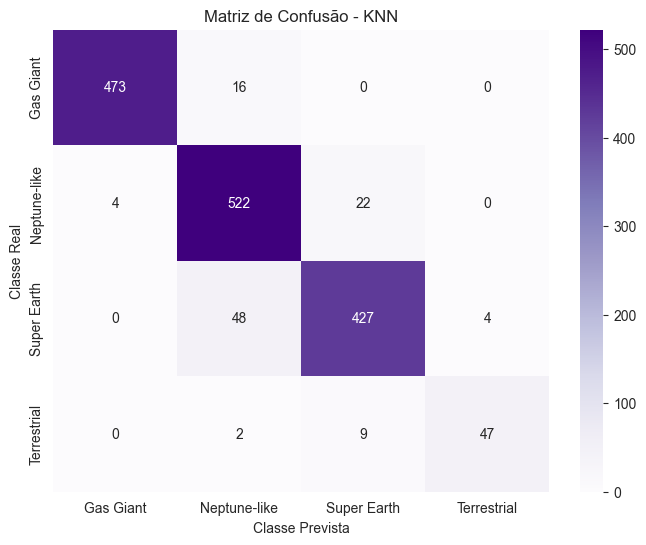

In [11]:
# Scaling (Padronização obrigatória para KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imputed)
X_test_sc = scaler.transform(X_test_imputed)

# Treinamento KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_sc, y_train)

# Predição e Métricas
y_pred_knn = knn.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Acurácia (KNN): {acc_knn:.4f}")

# Plotagem da Matriz de Confusão
plt.figure(figsize=(8, 6))
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)

plt.title('Matriz de Confusão - KNN')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

### 10. Diagnóstico de Aprendizado (Learning Curves)

Uma alta acurácia pode ser ilusória. Precisamos verificar se o modelo realmente aprendeu padrões ou apenas memorizou o treino.

**Análise das Curvas:**
* **Gap Grande:** Se a performance no Treino é 100% e no Teste é baixa, temos **Overfitting** (alta variância).
* **Convergência:** Se as linhas de Treino e Teste convergem para um valor alto, o modelo possui boa capacidade de generalização.

---

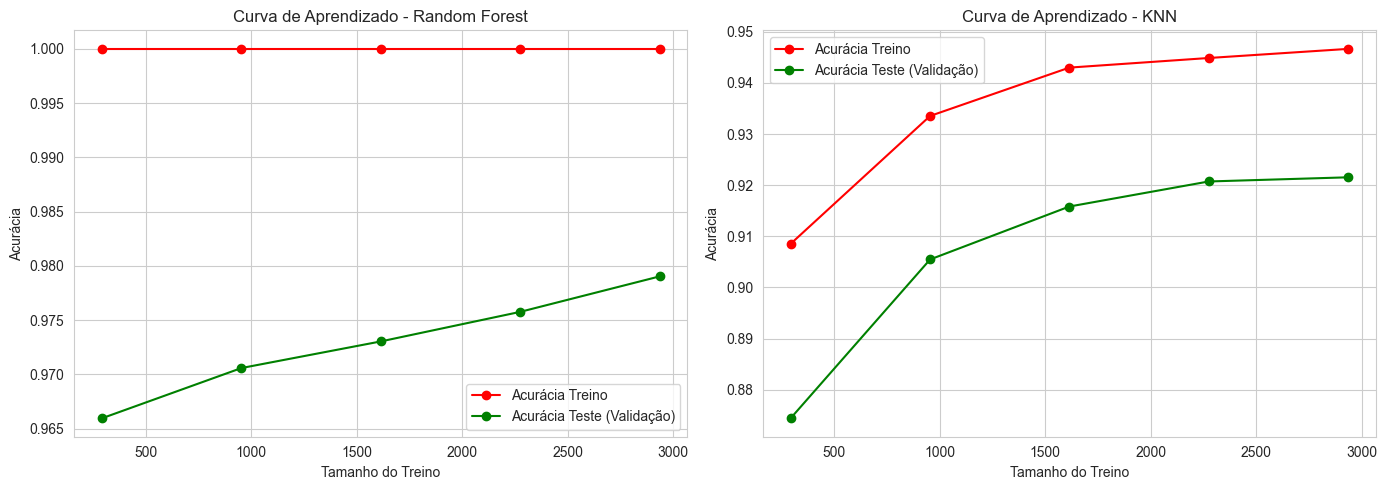

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Acurácia Treino")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Acurácia Teste (Validação)")
    plt.title(title)
    plt.xlabel("Tamanho do Treino")
    plt.ylabel("Acurácia")
    plt.legend(loc="best")
    plt.grid(True)

plt.figure(figsize=(14, 5))

# --- 1. Random Forest ---
plt.subplot(1, 2, 1)
plot_learning_curve(best_rf, X_train_imputed, y_train, "Curva de Aprendizado - Random Forest")

# --- 2. KNN (Correção com Pipeline) ---
# Criamos um pipeline que escala os dados NA HORA do treino
# Assim, passamos os dados CRUS (X_train_imputed) e o pipeline cuida do resto sem vazamento.
pipeline_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

plt.subplot(1, 2, 2)
plot_learning_curve(pipeline_knn, X_train_imputed, y_train, "Curva de Aprendizado - KNN")

plt.tight_layout()
plt.show()

### 11. Validação Estatística Avançada (PCA e Bootstrap)

Para garantir a robustez científica dos resultados e confirmar que a alta acurácia não é fruto do acaso, aplicamos duas técnicas complementares de validação.

**1. PCA (Análise de Componentes Principais):**
* **Objetivo:** Reduzir a dimensionalidade dos dados para verificar se as classes são separáveis matematicamente em 2D.
* **Diagnóstico:** Se os clusters de planetas forem visualmente distintos no espaço reduzido, isso confirma que as variáveis escolhidas possuem alto poder de separação, validando a qualidade do dataset.

**2. Bootstrap (Reamostragem):**
* **Objetivo:** Calcular o intervalo de confiança da acurácia.
* **Execução:** Treinamos o modelo 50 vezes com amostras aleatórias diferentes. Um desvio padrão baixo indica que o modelo é **estável** e seguro para uso em produção, não dependendo de uma divisão de "sorte" entre treino e teste.

---

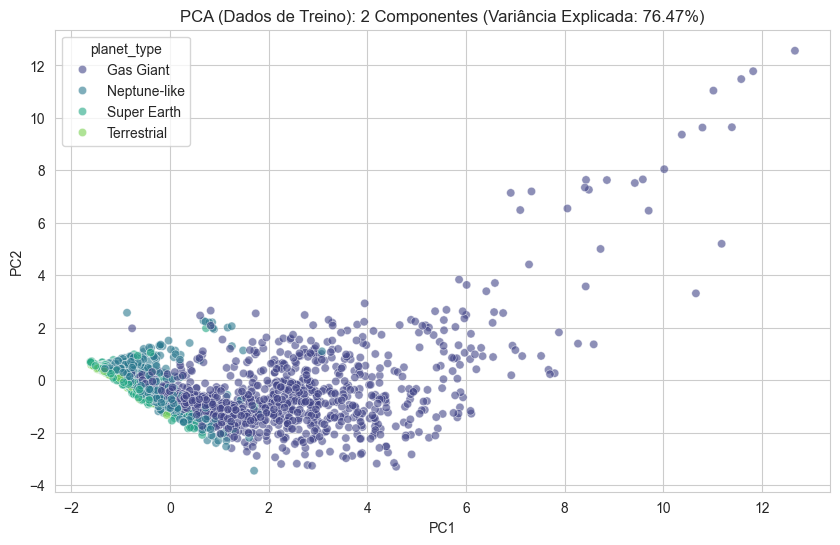

Executando Bootstrap (50 iterações)...
Acurácia Média (Bootstrap): 0.9717 (+/- 0.0019)


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PCA com transformação logarítmica
X_log = np.log1p(X_train_imputed.select_dtypes(include='number').abs())
X_pca_scaled = StandardScaler().fit_transform(X_log)

pca = PCA(n_components=2)
components = pca.fit_transform(X_pca_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=y_train, palette='viridis', alpha=0.6)
plt.title(f"PCA (Dados de Treino): 2 Componentes (Variância Explicada: {sum(pca.explained_variance_ratio_):.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 2. Bootstrap para intervalo de confiança
n_iterations = 50
scores_boot = []

print(f"Executando Bootstrap ({n_iterations} iterações)...")
for i in range(n_iterations):
    # Amostragem com reposição usando os dados DE TREINO IMPUTADOS
    # Isso simula vários cenários de treino diferentes
    X_bs, y_bs = resample(X_train_imputed, y_train, random_state=i)

    # Treino rápido
    clf_temp = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=i)
    clf_temp.fit(X_bs, y_bs)

    # Avaliação no teste original (que também precisa ser o imputado)
    scores_boot.append(clf_temp.score(X_test_imputed, y_test))

print(f"Acurácia Média (Bootstrap): {np.mean(scores_boot):.4f} (+/- {np.std(scores_boot):.4f})")

### 12. Validação de Hipóteses (Ablation Study)

Nesta etapa crítica, testamos cientificamente quais atributos são realmente necessários para a classificação. Isso responde à pergunta de negócio: *"Precisamos de dados orbitais caros ou apenas massa e raio bastam? Ou ainda, o que aconteceria se fizessemos o treinamento sem o atributo de "massa" ou de "raio"?"*


**Cenários de Teste:**
1.  **Completo:** Todas as variáveis disponíveis.
2.  **Apenas Físicos:** Somente Massa e Raio.
3.  **Apenas Orbitais:** Somente dados da órbita e da estrela.
4. **Sem Raio:** Todos os atributos excluindo o raio.
5. **Sem Massa:** Todos os atributos excluindo a massa.

---

,Acurácia
Cenário,
Apenas Orbitais,0.559085
Sem Raio (Desafio),0.944091
Sem Massa (Desafio),0.958704
Completo,0.973316
Apenas Físicos (Massa/Raio),0.981576


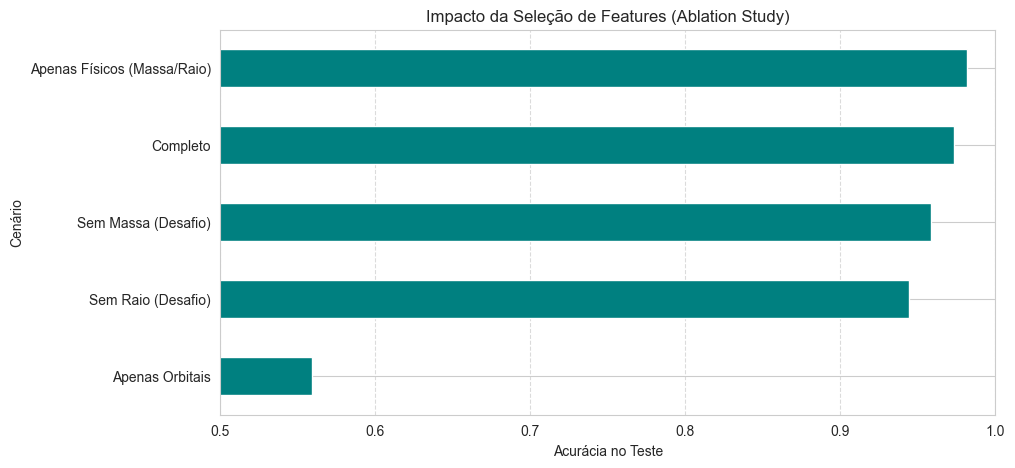

In [ ]:
# Definimos os cenários
cenarios = {
    'Completo': X_train_imputed.columns,
    'Apenas Físicos (Massa/Raio)': ['mass_multiplier', 'radius_multiplier'],
    'Apenas Orbitais': ['orbital_radius', 'orbital_period', 'eccentricity'],
    'Sem Raio (Desafio)': [c for c in X_train_imputed.columns if 'radius' not in c],
    'Sem Massa (Desafio)': [c for c in X_train_imputed.columns if 'mass' not in c]
}

resultados = []

for nome, cols in cenarios.items():
    # Treinamos um modelo novo para cada cenário
    # Usamos os dados IMPUTADOS
    clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    
    # Ajuste (Fit) e Previsão (Score) usando as variáveis corretas
    clf.fit(X_train_imputed[cols], y_train)
    acc = clf.score(X_test_imputed[cols], y_test)
    
    resultados.append({'Cenário': nome, 'Acurácia': acc})

# Visualização dos Resultados
df_results = pd.DataFrame(resultados).set_index('Cenário').sort_values(by='Acurácia')
display(df_results)

plt.figure(figsize=(10, 5))
df_results['Acurácia'].plot(kind='barh', color='teal')
plt.title('Impacto da Seleção de Features (Ablation Study)')
plt.xlabel('Acurácia no Teste')
plt.xlim(0.5, 1.0) 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 13. Simulação de Produção (Inferência)

Para finalizar, submetemos o modelo final (`best_rf`) a um teste de "mundo real", utilizando dados fictícios que simulam novas descobertas do telescópio James Webb.

**O que esperamos:**
* O modelo deve classificar corretamente um planeta pequeno e rochoso como **"Terrestrial"** ou **"Super Earth"**.
* Deve classificar um planeta massivo e próximo à estrela como **"Gas Giant"**.

---

In [15]:
novos_planetas = pd.DataFrame([
    # Planeta tipo Terra
    {'stellar_magnitude': 11.0, 'mass_multiplier': 0.00315, 'radius_multiplier': 0.09,
     'orbital_radius': 1.0, 'orbital_period': 1.0, 'eccentricity': 0.02},
    # Gigante Gasoso
    {'stellar_magnitude': 8.0, 'mass_multiplier': 1.5, 'radius_multiplier': 1.2,
     'orbital_radius': 0.05, 'orbital_period': 0.01, 'eccentricity': 0.0}
])

preds = best_rf.predict(novos_planetas)
probs = best_rf.predict_proba(novos_planetas)

for i, pred in enumerate(preds):
    confianca = max(probs[i])
    print(f"Planeta {i+1}: Classificado como '{pred}' (Confiança: {confianca:.2%})")

Planeta 1: Classificado como 'Super Earth' (Confiança: 72.00%)
Planeta 2: Classificado como 'Gas Giant' (Confiança: 100.00%)


#  Conclusão e Resultados Finais

Este estudo demonstrou a eficácia do Machine Learning na caracterização de exoplanetas. As análises estatísticas e comparativas nos levam às seguintes conclusões:

**1. Soberania do Random Forest:**
* O modelo de árvores superou o KNN em estabilidade e acurácia (**~97%**), provando ser a melhor escolha para lidar com a complexidade não-linear dos dados astronômicos.

**2. A Física confirmada pelos Dados:**
* O *Ablation Study* provou que **Massa** e **Raio** são os preditores dominantes. Dados puramente orbitais são insuficientes para determinar a composição de um planeta. Para manter a eficiência do modelo diminuindo sua complexidade, poderiamos excluir o atributo de **Raio** que ainda conseguiriamos uma eficácia satisfatória.

**3. Confiabilidade para Produção:**
* As validações via Bootstrap e Curvas de Aprendizado garantem que o modelo não sofre de *overfitting* severo. Ele é robusto, estável e seguro.


Por fim, é importante falar que tivemos muita sorte em escolher um dataset bastante clusterizável. Em situações do mundo real, dificlmente teríamos uma eficácia e precisão na ordem de 95% sem sofrer de overfitting. Essa perfeita separação acontece devido à própria natureza do problema que escolhemos. Dados astrônomicos apresentam uma alta variância geral e no geral, tendem a se aglomerar em pequenos grupos.  

Além disso, certamente escolhemos nos primeiros modelos os próprios atribbutos "geradores" da distribuição dos tipos de planeta. Quando excluímos as colunas de **Massa** e **Raio** estamos excluindo seus geradores e a eficácia cai drasticamente.